# Classifying on My Clusters

In [4]:
# Libraries
# Libraries from snr_intro.ipynb
# data manipulation 
import pandas as pd
import numpy as np

# plotting
import seaborn as sns
import matplotlib.pyplot as plt

# Extra libraries from week6 MLP (logistic regression)
# sklearn modules
import sklearn
from sklearn.linear_model import LogisticRegression

# Other necessary packages
from sklearn.preprocessing import StandardScaler  # scaling features
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import make_pipeline # combining classifier steps
from sklearn.pipeline import Pipeline 
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import GridSearchCV, KFold, StratifiedKFold 
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay


# Classifiers
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

# For retraining and exporting best classifier to another spreadsheet:
import joblib
from sklearn.base import clone

# ignore warnings:
import warnings
from sklearn.exceptions import UndefinedMetricWarning

warnings.filterwarnings(
    "ignore",
    category=UndefinedMetricWarning
)

In [5]:
ec_snr_data = pd.read_csv("Data/ec_snr_data_with_clusters.csv")

label_map = {
    0: "long_xlong_STRd_STRv_AI^ORB~very_lateral",
    1: "med_short_RSP_VIS^RSP~very_medial",
    2: "med_xlong_RSP_VIS_STR^blend~medial",
    3: "short_HIP_SUB^RSP~very_medial",
    4: "med_RSP_VIS_TEa^blend~medial",
    5: "med_AMY_STRv_STRd^ORB~very_lateral",
    6: "xshort_mixed^none~medial"
}

cluster_label_order = [3, 1, 2, 5, 0, 4, 6]
cluster_order = [label_map[i] for i in cluster_label_order]

In [6]:
X = ec_snr_data[['x','y','z']]
y = ec_snr_data['label_names']

X_train, X_test, y_train, y_test = train_test_split(X,y,train_size=0.8, stratify=y, shuffle=True, random_state=24600)


In [7]:
ec_snr_data[['x','y','z']].describe()

,x,y,z
count,237.000000,237.000000,237.000000
mean,9661.518979,3882.841267,9484.916677
std,520.107649,732.917537,359.285069
min,7755.641480,2209.400000,8751.366239
25%,9619.300000,3375.510025,9231.339455
50%,9865.100000,3861.000000,9446.899605
75%,9978.488159,4326.364136,9756.100000
max,10184.860230,5720.488040,10250.971840


# Common grids/parameters/metrics

In [8]:
scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "f1_macro": "f1_macro",
    "recall_macro": "recall_macro",
    "precision_macro": "precision_macro"
}


cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=4
)

# Knn

## No scaling

In [9]:
knn_pipe_raw = make_pipeline(
    KNeighborsClassifier()
)
param_grid = {
    "kneighborsclassifier__n_neighbors": range(1,50),
    "kneighborsclassifier__weights": ["uniform", "distance"]
}


knn_grid_raw = GridSearchCV(
    knn_pipe_raw,
    param_grid=param_grid,
    scoring=scoring,
    refit="f1_macro",   # chooses best model using this metric
    cv=cv,
    return_train_score=True
)

knn_grid_raw.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'kneighborsclassifier__n_neighbors': range(1, 50), 'kneighborsclassifier__weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'accuracy': 'accuracy', 'balanced_accuracy': 'balanced_accuracy', 'f1_macro': 'f1_macro', 'precision_macro': 'precision_macro', ...}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'f1_macro'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",Stratifi

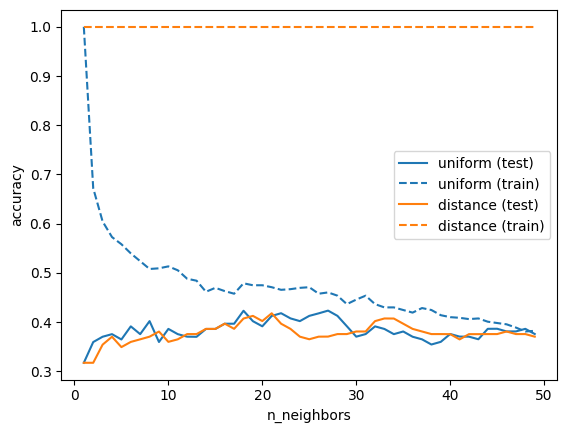

In [10]:
knn_raw_results = pd.DataFrame(knn_grid_raw.cv_results_)

for weight in ["uniform", "distance"]:
    subset = knn_raw_results[
        knn_raw_results["param_kneighborsclassifier__weights"] == weight
    ]

    line = plt.plot(
        subset["param_kneighborsclassifier__n_neighbors"],
        subset["mean_test_accuracy"],
        label=f"{weight} (test)"
    )[0]

    plt.plot(
        subset["param_kneighborsclassifier__n_neighbors"],
        subset["mean_train_accuracy"],
        "--",
        color=line.get_color(),
        label=f"{weight} (train)"
    )

plt.xlabel("n_neighbors")
plt.ylabel("accuracy")
plt.legend()
plt.show()

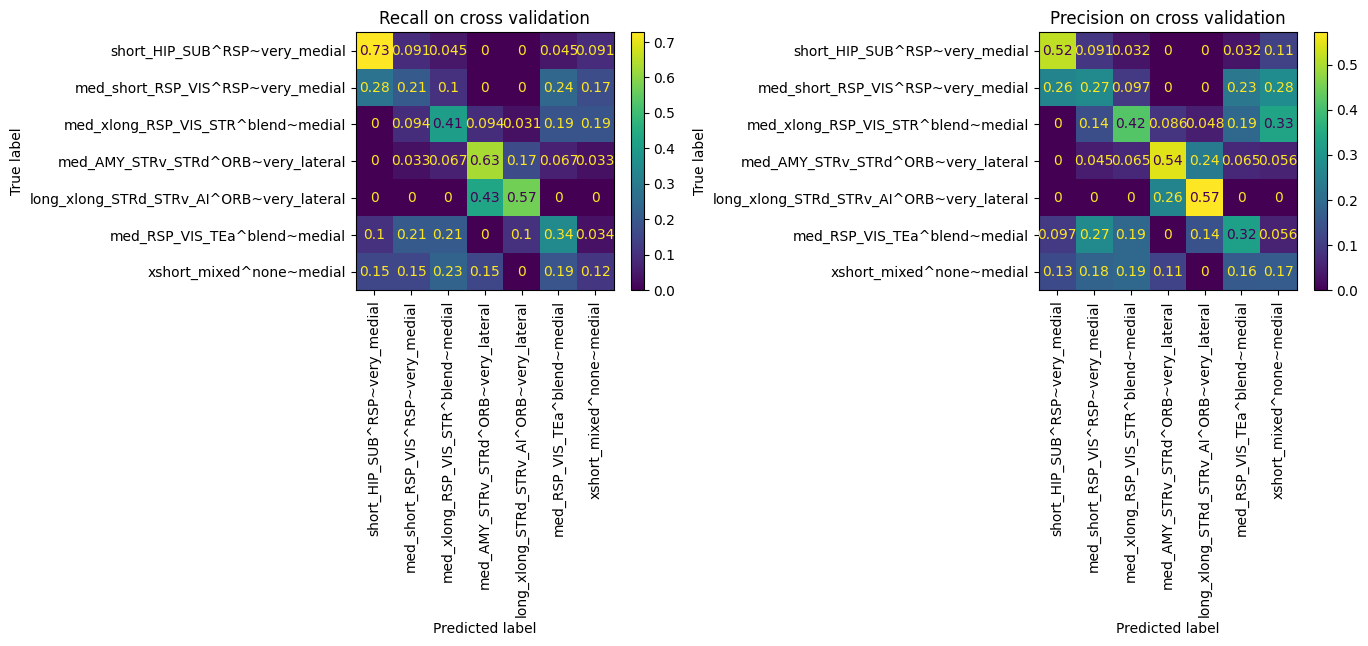

In [11]:
knn_raw_pred = cross_val_predict(
    knn_grid_raw.best_estimator_,
    X_train,
    y_train,
    cv=cv,
    n_jobs=-1
)

fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 6)
)

ConfusionMatrixDisplay.from_predictions(
    y_train,
    knn_raw_pred,
    normalize="true",
    labels=cluster_order,
    xticks_rotation=90,
    ax=axes[0]
)

axes[0].set_title("Recall on cross validation")

ConfusionMatrixDisplay.from_predictions(
    y_train,
    knn_raw_pred,
    normalize="pred",
    xticks_rotation=90,
    labels=cluster_order,
    ax=axes[1]
)

axes[1].set_title("Precision on cross validation")

plt.tight_layout()
plt.show()

In [12]:
knn_raw_cr = classification_report(y_train, knn_raw_pred)
print(knn_raw_cr)


                                          precision    recall  f1-score   support

long_xlong_STRd_STRv_AI^ORB~very_lateral       0.57      0.57      0.57        21
      med_AMY_STRv_STRd^ORB~very_lateral       0.54      0.63      0.58        30
            med_RSP_VIS_TEa^blend~medial       0.32      0.34      0.33        29
       med_short_RSP_VIS^RSP~very_medial       0.27      0.21      0.24        29
      med_xlong_RSP_VIS_STR^blend~medial       0.42      0.41      0.41        32
           short_HIP_SUB^RSP~very_medial       0.52      0.73      0.60        22
                xshort_mixed^none~medial       0.17      0.12      0.14        26

                                accuracy                           0.42       189
                               macro avg       0.40      0.43      0.41       189
                            weighted avg       0.40      0.42      0.40       189



## Scaling

In [13]:
knn_pipe_scale = make_pipeline(
    ColumnTransformer([("scale", StandardScaler(),['x','y','z'])], 
                      remainder = 'passthrough'),
    KNeighborsClassifier()
)
param_grid = {
    "kneighborsclassifier__n_neighbors": [1, 2, 5, 10, 20, 30, 40, 50, 60],
    "kneighborsclassifier__weights": ["uniform", "distance"]
}

cv = StratifiedKFold(
    n_splits=4,
    shuffle=True,
    random_state=4
)

knn_grid_scale = GridSearchCV(
    knn_pipe_scale,
    param_grid=param_grid,
    scoring=scoring,
    refit="f1_macro",   # chooses best model using this metric
    cv=cv,
    return_train_score=True
)

knn_grid_scale.fit(X_train, y_train)
print(knn_pipe_scale.named_steps)




{'columntransformer': ColumnTransformer(remainder='passthrough',
                  transformers=[('scale', StandardScaler(), ['x', 'y', 'z'])]), 'kneighborsclassifier': KNeighborsClassifier()}


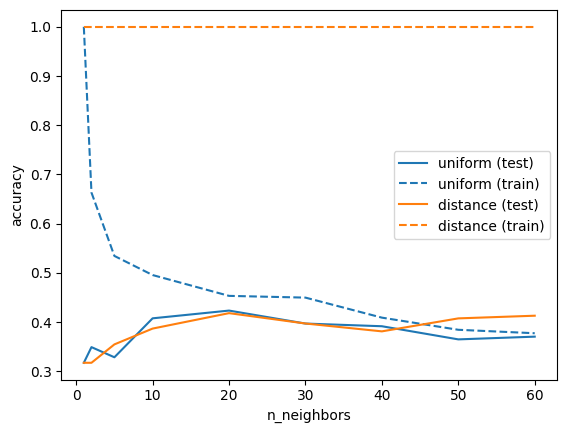

In [14]:
knn_scale_results = pd.DataFrame(knn_grid_scale.cv_results_)
for weight in ["uniform", "distance"]:
    subset = knn_scale_results[
        knn_scale_results["param_kneighborsclassifier__weights"] == weight
    ]

    line = plt.plot(
        subset["param_kneighborsclassifier__n_neighbors"],
        subset["mean_test_accuracy"],
        label=f"{weight} (test)"
    )[0]

    plt.plot(
        subset["param_kneighborsclassifier__n_neighbors"],
        subset["mean_train_accuracy"],
        "--",
        color=line.get_color(),
        label=f"{weight} (train)"
    )

plt.xlabel("n_neighbors")
plt.ylabel("accuracy")
plt.legend()
plt.show()

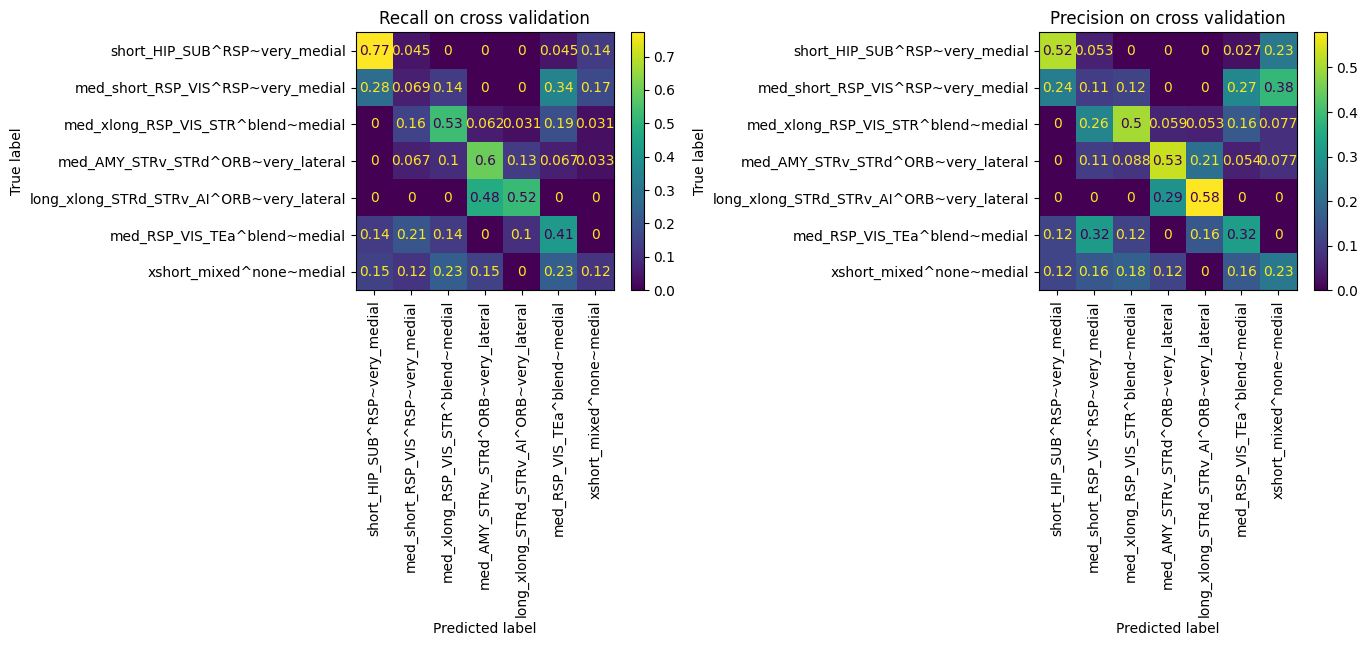

In [15]:
knn_scale_pred = cross_val_predict(
    knn_grid_scale.best_estimator_,
    X_train,
    y_train,
    cv=cv,
    n_jobs=-1
)

fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 6)
)

ConfusionMatrixDisplay.from_predictions(
    y_train,
    knn_scale_pred,
    normalize="true",
    labels=cluster_order,
    xticks_rotation=90,
    ax=axes[0]
)

axes[0].set_title("Recall on cross validation")

ConfusionMatrixDisplay.from_predictions(
    y_train,
    knn_scale_pred,
    normalize="pred",
    labels=cluster_order,
    xticks_rotation=90,
    ax=axes[1]
)

axes[1].set_title("Precision on cross validation")

plt.tight_layout()
plt.show()

In [16]:
knn_scale_cr = classification_report(y_train, knn_scale_pred)
print(knn_scale_cr)

                                          precision    recall  f1-score   support

long_xlong_STRd_STRv_AI^ORB~very_lateral       0.58      0.52      0.55        21
      med_AMY_STRv_STRd^ORB~very_lateral       0.53      0.60      0.56        30
            med_RSP_VIS_TEa^blend~medial       0.32      0.41      0.36        29
       med_short_RSP_VIS^RSP~very_medial       0.11      0.07      0.08        29
      med_xlong_RSP_VIS_STR^blend~medial       0.50      0.53      0.52        32
           short_HIP_SUB^RSP~very_medial       0.52      0.77      0.62        22
                xshort_mixed^none~medial       0.23      0.12      0.15        26

                                accuracy                           0.42       189
                               macro avg       0.40      0.43      0.41       189
                            weighted avg       0.39      0.42      0.40       189



# Logistic Regression

In [17]:
logreg_pipe = make_pipeline(
    ColumnTransformer([("scale", StandardScaler(), ['x','y','z'])], remainder='passthrough'),
    LogisticRegression(
        max_iter=5000,
        solver="lbfgs"
    )
)

logreg_param_grid = {
    "logisticregression__C": np.logspace(-4, 4, 25)
}

logreg_grid = GridSearchCV(
    logreg_pipe,
    param_grid=logreg_param_grid,
    scoring=scoring,
    refit="f1_macro",
    cv=cv,
    return_train_score=True,
    n_jobs=4
)

logreg_grid.fit(X_train, y_train)

best_logreg = logreg_grid.best_estimator_
logreg_grid.best_params_

{'logisticregression__C': np.float64(4.641588833612772)}

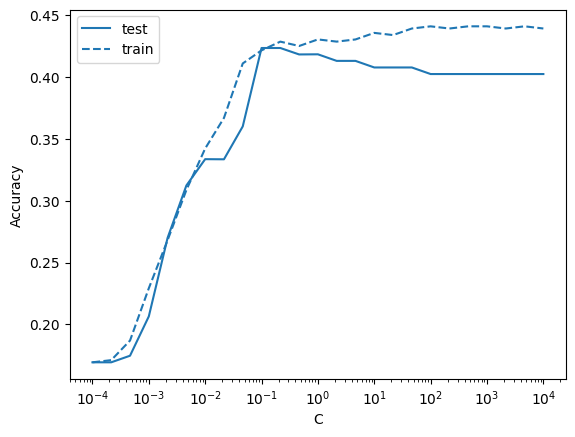

In [18]:
logreg_results = pd.DataFrame(logreg_grid.cv_results_)

line = plt.plot(
    logreg_results["param_logisticregression__C"],
    logreg_results["mean_test_accuracy"],
    label="test"
)[0]

plt.plot(
    logreg_results["param_logisticregression__C"],
    logreg_results["mean_train_accuracy"],
    "--",
    color=line.get_color(),
    label="train"
)
plt.xscale("log")
plt.xlabel("C")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

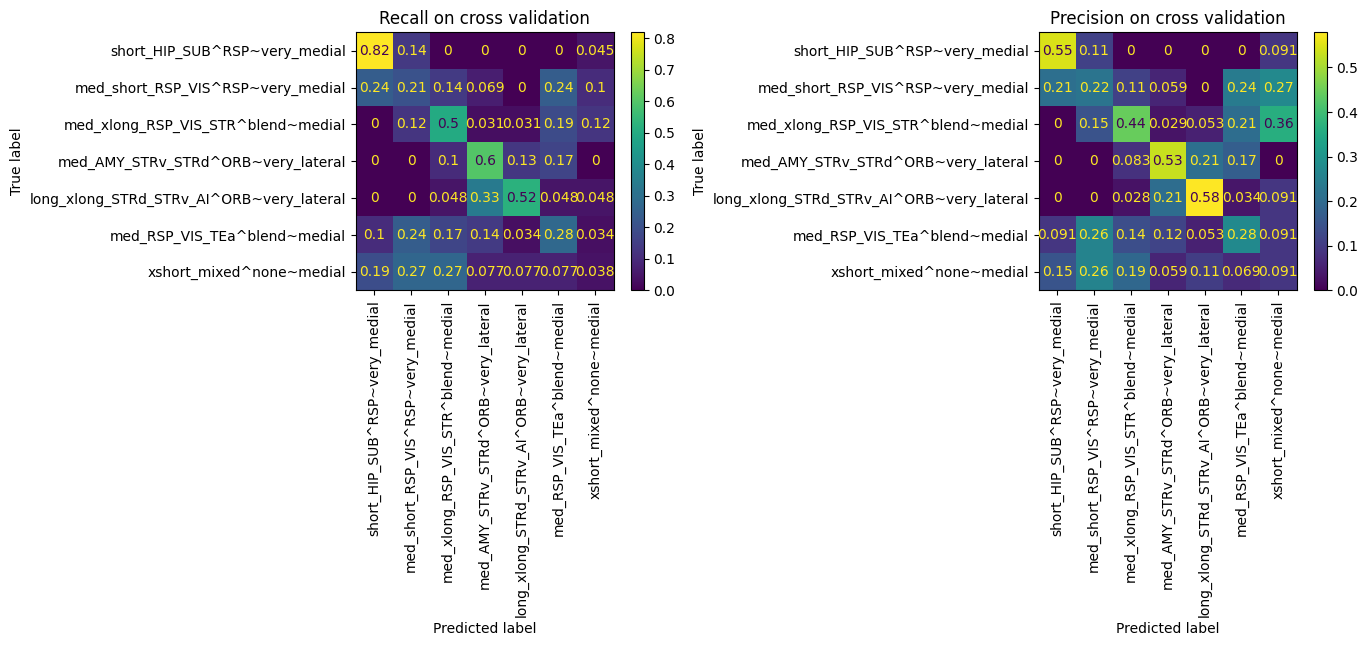

In [19]:
logreg_pred = cross_val_predict(
    logreg_grid.best_estimator_,
    X_train,
    y_train,
    cv=cv,
    n_jobs=-1
)

fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 6)
)

ConfusionMatrixDisplay.from_predictions(
    y_train,
    logreg_pred,
    normalize="true",
    xticks_rotation=90,
    labels=cluster_order,
    ax=axes[0]
)

axes[0].set_title("Recall on cross validation")

ConfusionMatrixDisplay.from_predictions(
    y_train,
    logreg_pred,
    normalize="pred",
    xticks_rotation=90,
    labels=cluster_order,
    ax=axes[1]
)

axes[1].set_title("Precision on cross validation")

plt.tight_layout()
plt.show()

In [20]:
logreg_cr = classification_report(y_train, logreg_pred)
print(logreg_cr)

                                          precision    recall  f1-score   support

long_xlong_STRd_STRv_AI^ORB~very_lateral       0.58      0.52      0.55        21
      med_AMY_STRv_STRd^ORB~very_lateral       0.53      0.60      0.56        30
            med_RSP_VIS_TEa^blend~medial       0.28      0.28      0.28        29
       med_short_RSP_VIS^RSP~very_medial       0.22      0.21      0.21        29
      med_xlong_RSP_VIS_STR^blend~medial       0.44      0.50      0.47        32
           short_HIP_SUB^RSP~very_medial       0.55      0.82      0.65        22
                xshort_mixed^none~medial       0.09      0.04      0.05        26

                                accuracy                           0.41       189
                               macro avg       0.38      0.42      0.40       189
                            weighted avg       0.38      0.41      0.39       189



# SVM with RBF kernel

In [21]:
svm_pipe = make_pipeline(
    ColumnTransformer([("scale", StandardScaler(), ['x','y','z'])], remainder='passthrough'),
    SVC(kernel="rbf", probability=True)
)

svm_param_grid = {
    "svc__C": np.logspace(-4, 4, 50),
    "svc__gamma": np.logspace(-4, 4, 50)
}

svm_grid = GridSearchCV(
    svm_pipe,
    param_grid=svm_param_grid,
    scoring=scoring,
    refit="f1_macro",
    cv=cv,
    return_train_score=True,
    n_jobs=-1
)

svm_grid.fit(X_train, y_train)

best_svm = svm_grid.best_estimator_



In [22]:
svm_grid.best_params_

{'svc__C': np.float64(24.420530945486497),
 'svc__gamma': np.float64(0.05963623316594643)}

In [23]:
best_svm[-1].n_support_

array([17, 25, 29, 29, 30, 17, 26], dtype=int32)

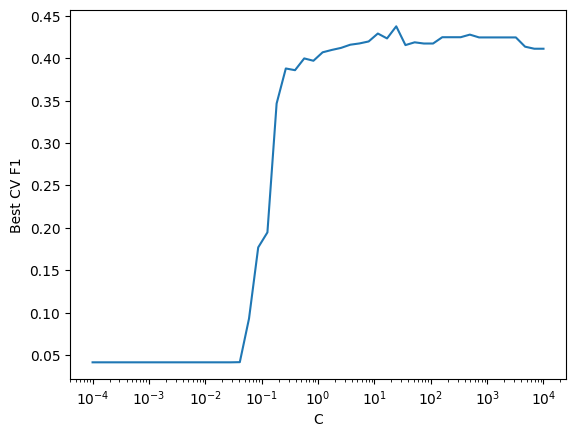

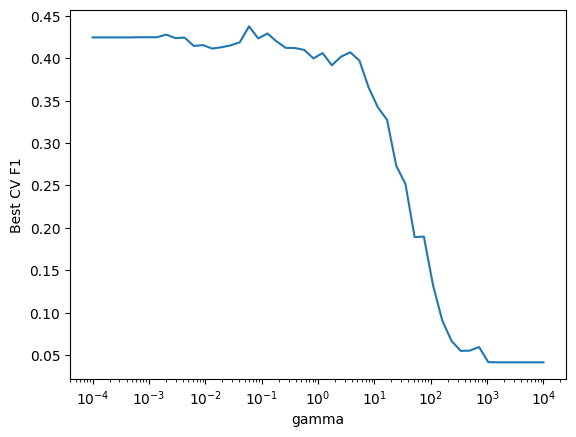

In [24]:
svm_results = pd.DataFrame(svm_grid.cv_results_)

best_by_C = (
    svm_results
    .groupby("param_svc__C")["mean_test_f1_macro"]
    .max()
)

plt.plot(best_by_C.index, best_by_C.values)
plt.xscale("log")
plt.xlabel("C")
plt.ylabel("Best CV F1")
plt.show()

best_by_gamma = (
    svm_results
    .groupby("param_svc__gamma")["mean_test_f1_macro"]
    .max()
)

plt.plot(best_by_gamma.index, best_by_gamma.values)
plt.xscale("log")
plt.xlabel("gamma")
plt.ylabel("Best CV F1")
plt.show()

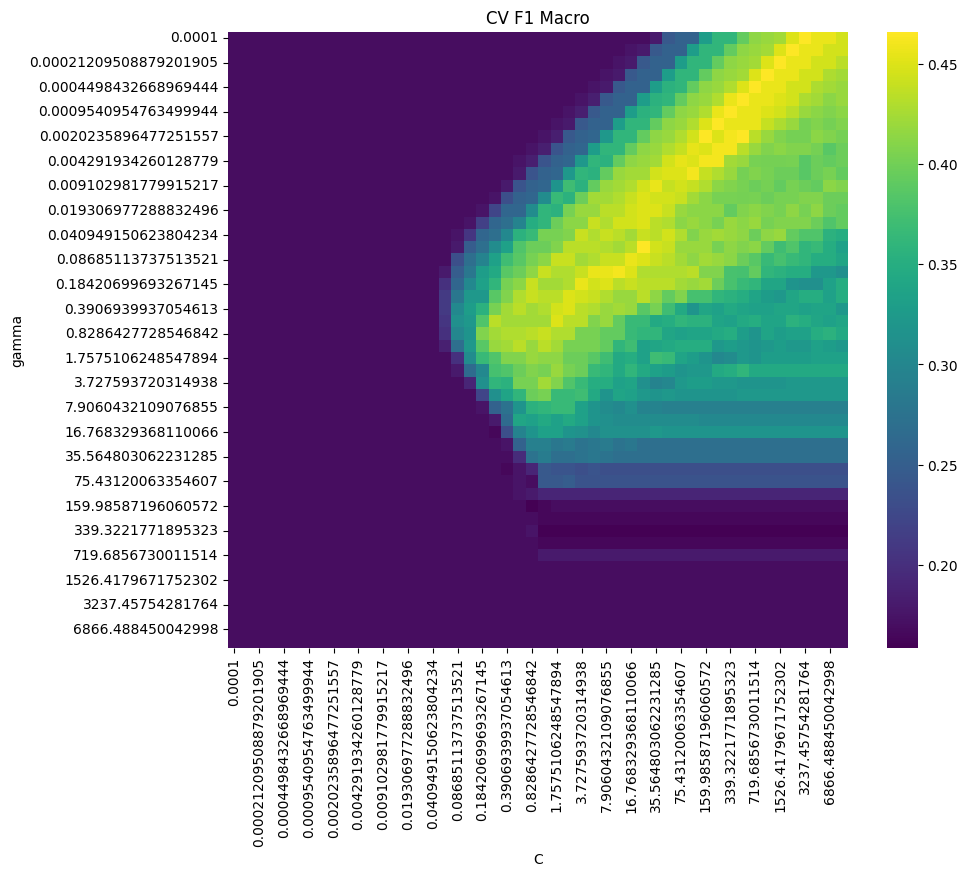

In [25]:
pivot = svm_results.pivot_table(
    values="mean_test_accuracy",
    index="param_svc__gamma",
    columns="param_svc__C"
)

plt.figure(figsize=(10,8))

sns.heatmap(
    pivot,
    cmap="viridis"
)

plt.xlabel("C")
plt.ylabel("gamma")
plt.title("CV F1 Macro")
pivot.index = np.round(np.log10(pivot.index.astype(float)), 2)
pivot.columns = np.round(np.log10(pivot.columns.astype(float)), 2)
plt.show()

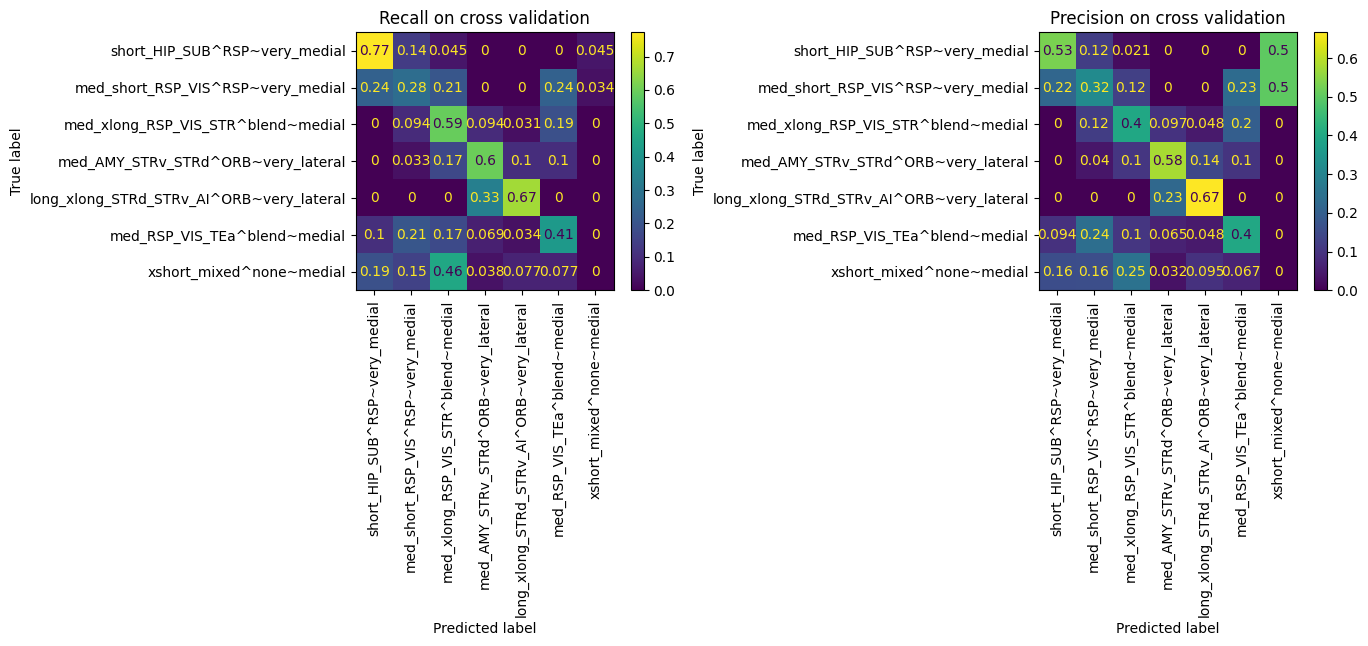

In [26]:
svm_pred = cross_val_predict(
    svm_grid.best_estimator_,
    X_train,
    y_train,
    cv=cv,
    n_jobs=-1
)

fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 6)
)

ConfusionMatrixDisplay.from_predictions(
    y_train,
    svm_pred,
    normalize="true",
    xticks_rotation=90,
    labels=cluster_order,
    ax=axes[0]
)

axes[0].set_title("Recall on cross validation")

ConfusionMatrixDisplay.from_predictions(
    y_train,
    svm_pred,
    normalize="pred",
    xticks_rotation=90,
    labels=cluster_order,
    ax=axes[1]
)

axes[1].set_title("Precision on cross validation")

plt.tight_layout()

plt.show()

In [27]:
svm_cr = classification_report(y_train, svm_pred)
print(svm_cr)

                                          precision    recall  f1-score   support

long_xlong_STRd_STRv_AI^ORB~very_lateral       0.67      0.67      0.67        21
      med_AMY_STRv_STRd^ORB~very_lateral       0.58      0.60      0.59        30
            med_RSP_VIS_TEa^blend~medial       0.40      0.41      0.41        29
       med_short_RSP_VIS^RSP~very_medial       0.32      0.28      0.30        29
      med_xlong_RSP_VIS_STR^blend~medial       0.40      0.59      0.47        32
           short_HIP_SUB^RSP~very_medial       0.53      0.77      0.63        22
                xshort_mixed^none~medial       0.00      0.00      0.00        26

                                accuracy                           0.47       189
                               macro avg       0.41      0.47      0.44       189
                            weighted avg       0.41      0.47      0.43       189



# Decision Tree

In [28]:
tree_pipe = Pipeline([
    ("tree", DecisionTreeClassifier(random_state=42))
])

tree_param_grid = {
    "tree__max_depth": [2, 3, 4, 5, 6, 10, 50, 100, None],
    "tree__min_samples_leaf": [1, 2, 5, 10, 20, 50, 100],
    "tree__criterion": ["gini", "entropy"]
}

tree_grid = GridSearchCV(
    tree_pipe,
    param_grid=tree_param_grid,
    scoring=scoring,
    refit="f1_macro",
    cv=cv,
    return_train_score=True,
    n_jobs=-1
)

tree_grid.fit(X_train, y_train)

best_tree = tree_grid.best_estimator_

tree_grid.best_params_

{'tree__criterion': 'gini', 'tree__max_depth': 6, 'tree__min_samples_leaf': 5}

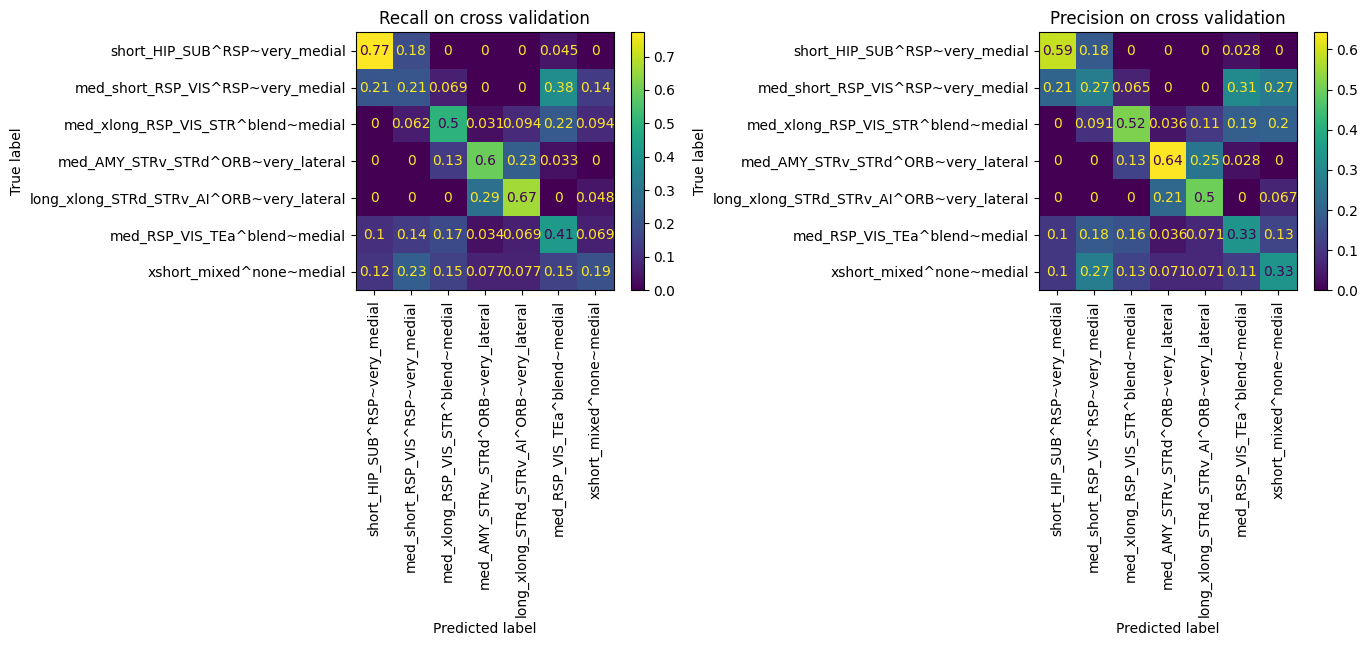

In [29]:
tree_pred = cross_val_predict(
    tree_grid.best_estimator_,
    X_train,
    y_train,
    cv=cv,
    n_jobs=-1
)

fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 6)
)

ConfusionMatrixDisplay.from_predictions(
    y_train,
    tree_pred,
    normalize="true",
    xticks_rotation=90,
    labels=cluster_order,
    ax=axes[0]
)

axes[0].set_title("Recall on cross validation")

ConfusionMatrixDisplay.from_predictions(
    y_train,
    tree_pred,
    normalize="pred",
    xticks_rotation=90,
    labels=cluster_order,
    ax=axes[1]
)

axes[1].set_title("Precision on cross validation")

plt.tight_layout()
plt.show()

In [30]:
tree_cr = classification_report(y_train, tree_pred)
print(tree_cr)

                                          precision    recall  f1-score   support

long_xlong_STRd_STRv_AI^ORB~very_lateral       0.50      0.67      0.57        21
      med_AMY_STRv_STRd^ORB~very_lateral       0.64      0.60      0.62        30
            med_RSP_VIS_TEa^blend~medial       0.33      0.41      0.37        29
       med_short_RSP_VIS^RSP~very_medial       0.27      0.21      0.24        29
      med_xlong_RSP_VIS_STR^blend~medial       0.52      0.50      0.51        32
           short_HIP_SUB^RSP~very_medial       0.59      0.77      0.67        22
                xshort_mixed^none~medial       0.33      0.19      0.24        26

                                accuracy                           0.47       189
                               macro avg       0.45      0.48      0.46       189
                            weighted avg       0.45      0.47      0.45       189



# Random Forest

In [31]:
rf_pipe = Pipeline([
    ("rf", RandomForestClassifier(random_state=42))
])

rf_param_grid = {
    "rf__n_estimators": [1, 2, 3, 5, 10, 25, 50, 100, 200],
    "rf__max_depth": [3, 5, 10, 20, 30, 40, 50, 75, 100, 200, None],
    "rf__min_samples_leaf": [1, 2, 5, 10, 20, 30, 40, 50, 75, 100],
    "rf__max_features": ["sqrt", None]
}

rf_grid = GridSearchCV(
    rf_pipe,
    param_grid=rf_param_grid,
    scoring=scoring,
    refit="f1_macro",
    cv=cv,
    return_train_score=True,
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

best_rf = rf_grid.best_estimator_

rf_grid.best_params_

{'rf__max_depth': 5,
 'rf__max_features': None,
 'rf__min_samples_leaf': 1,
 'rf__n_estimators': 100}

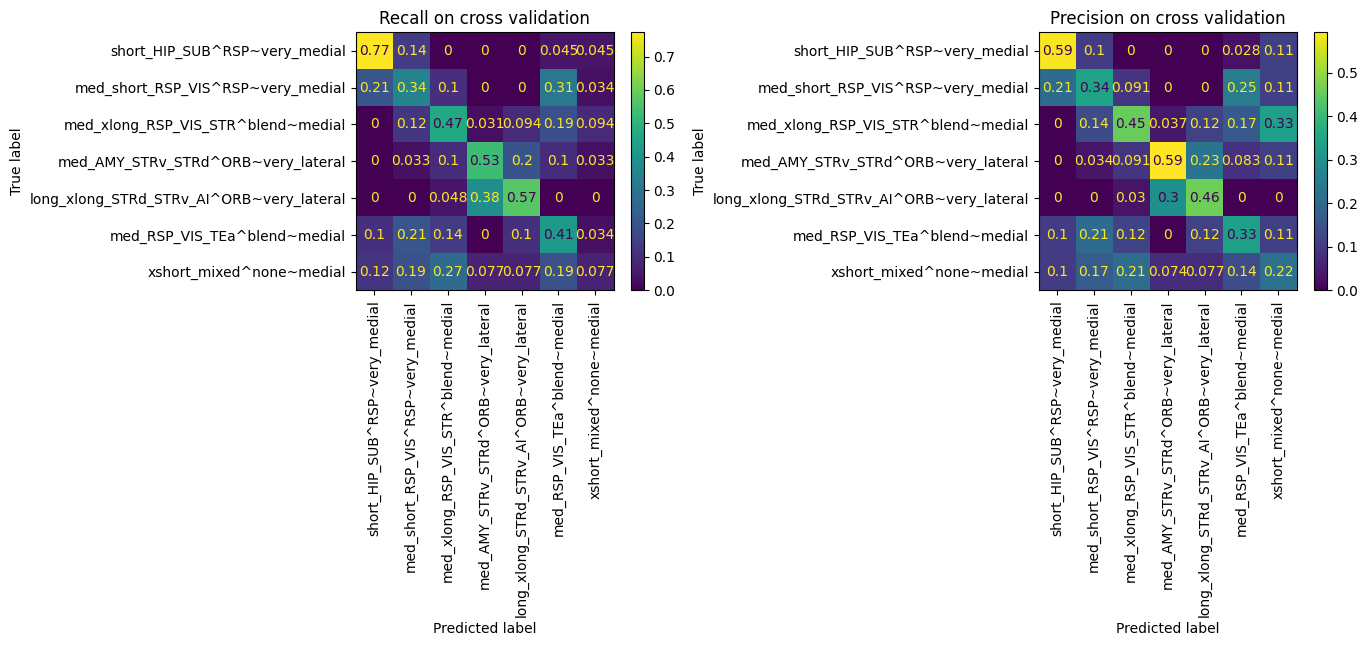

In [32]:
rf_pred = cross_val_predict(
    rf_grid.best_estimator_,
    X_train,
    y_train,
    cv=cv,
    n_jobs=-1
)

fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 6)
)

ConfusionMatrixDisplay.from_predictions(
    y_train,
    rf_pred,
    normalize="true",
    xticks_rotation=90,
    labels=cluster_order,
    ax=axes[0]
)

axes[0].set_title("Recall on cross validation")

ConfusionMatrixDisplay.from_predictions(
    y_train,
    rf_pred,
    normalize="pred",
    xticks_rotation=90,
    labels=cluster_order,
    ax=axes[1]
)

axes[1].set_title("Precision on cross validation")

plt.tight_layout()
plt.show()

In [33]:
rf_cr = classification_report(y_train, rf_pred)
print(rf_cr)

                                          precision    recall  f1-score   support

long_xlong_STRd_STRv_AI^ORB~very_lateral       0.46      0.57      0.51        21
      med_AMY_STRv_STRd^ORB~very_lateral       0.59      0.53      0.56        30
            med_RSP_VIS_TEa^blend~medial       0.33      0.41      0.37        29
       med_short_RSP_VIS^RSP~very_medial       0.34      0.34      0.34        29
      med_xlong_RSP_VIS_STR^blend~medial       0.45      0.47      0.46        32
           short_HIP_SUB^RSP~very_medial       0.59      0.77      0.67        22
                xshort_mixed^none~medial       0.22      0.08      0.11        26

                                accuracy                           0.44       189
                               macro avg       0.43      0.45      0.43       189
                            weighted avg       0.43      0.44      0.43       189



In [ ]:
# ============================================================
# 6. HistGradientBoostingClassifier
# ============================================================

hgb_pipe = Pipeline([
    ("hgb", HistGradientBoostingClassifier(random_state=42))
])

hgb_param_grid = {
    "hgb__learning_rate": np.logspace(-3,1,10),
    "hgb__max_iter": np.linspace(1,100,10, dtype=int),
    "hgb__max_leaf_nodes": [2, 7, 15],
    "hgb__l2_regularization": np.linspace(0,1,10)
}

hgb_grid = GridSearchCV(
    hgb_pipe,
    param_grid=hgb_param_grid,
    scoring=scoring,
    refit="f1_macro",
    cv=cv,
    return_train_score=True,
    n_jobs=-1
)

hgb_grid.fit(X_train, y_train)

best_hgb = hgb_grid.best_estimator_

hgb_grid.best_params_

In [ ]:
hgb_pred = cross_val_predict(
    hgb_grid.best_estimator_,
    X_train,
    y_train,
    cv=cv,
    n_jobs=-1
)

fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 6)
)

ConfusionMatrixDisplay.from_predictions(
    y_train,
    hgb_pred,
    normalize="true",
    xticks_rotation=90,
    labels=cluster_order,
    ax=axes[0]
)

axes[0].set_title("Recall on cross validation")

ConfusionMatrixDisplay.from_predictions(
    y_train,
    hgb_pred,
    normalize="pred",
    xticks_rotation=90,
    labels=cluster_order,
    ax=axes[1]
)

axes[1].set_title("Precision on cross validation")

plt.tight_layout()
plt.show()

In [ ]:
hgb_cr = classification_report(y_train, hgb_pred)
print(hgb_cr)

In [ ]:
summary_rows = []

for model_name, grid in [
    ("k-NN-raw", knn_grid_raw),
    ("k-NN-scale", knn_grid_scale),
    ("Logistic Regression", logreg_grid),
    ("Decision Tree", tree_grid),
    ("Random Forest", rf_grid),
    ("SVM RBF", svm_grid),
    ("HistGradientBoosting", hgb_grid)
]:
    best_idx = grid.best_index_

    summary_rows.append({
        "model": model_name,
        "best_params": grid.best_params_,
        "mean_cv_accuracy": grid.cv_results_["mean_test_accuracy"][best_idx],
        "mean_cv_balanced_accuracy": grid.cv_results_["mean_test_balanced_accuracy"][best_idx],
        "mean_cv_f1_macro": grid.cv_results_["mean_test_f1_macro"][best_idx],
        "mean_cv_recall_macro": grid.cv_results_["mean_test_recall_macro"][best_idx],
        "mean_cv_precision_macro": grid.cv_results_["mean_test_precision_macro"][best_idx],
    })

model_summary = pd.DataFrame(summary_rows)

model_summary.sort_values(
    "mean_cv_f1_macro",
    ascending=False
)

# Evaluation of Test error

In [ ]:
best_svm_test = svm_grid.best_estimator_



In [ ]:
test_pred = best_svm_test.predict(X_test)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_pred,
    normalize="true",
    xticks_rotation=90,
    labels=cluster_order)

plt.savefig(
    "Figures/fig_10_confusionmatrix.png",
    bbox_inches="tight",
    facecolor="white"
)
plt.show()

In [ ]:
print(classification_report(y_test, test_pred))

In [ ]:
final_svm = clone(best_svm)

final_svm.fit(X, y)

In [ ]:
joblib.dump(final_svm, "Models/best_cluster_classifier.pkl")